# 24-Hour Fuel Scheduling LP with Fuel Inventory Management

This notebook formulates a **linear programming (LP)** problem for the 24-hour operation of three thermal generators: **Coal**, **Gas**, and **Diesel**.

The optimizer minimizes total fuel cost while satisfying hourly electricity demand, generator capacity limits, and dynamic fuel inventory balances.

Fuel inventories and deliveries are measured in **tons**, while the connection between fuel mass and electrical generation is made through the generator heat rate and fuel heating value.

For generator $g$ and hour $t$:

$$\text{Fuel used}_{g,t}=\frac{h_g P_{g,t}\Delta t}{H_g}$$

where $h_g$ is the heat rate in GJ/MWh and $H_g$ is the fuel heating value in GJ/ton.

## 1. Mathematical formulation

### Decision variables

* $P_{g,t}$ is the power output of generator $g$ during hour $t$ [MW]
* $M_{g,t}$ is end-of-hour fuel inventory for generator $g$ [tons]

### Fixed parameters

* $D_t$ denotes electricity demand during hour $t$ [MW]
* $P_g^{\max}$ is the maximum generator output [MW]. $P_g^{\min}$ is zero.
* $h_g$ is the heat rate of generator $g$ [GJ/MWh]
* $H_g$ is the fuel heating value of the fuel for generator $g$ [GJ/ton]
* $c_g$ is the fuel price of the fuel for generator $g$ [PHP/ton]
* $M_{g,0}$ is the initial fuel inventory for generator $g$ [ton]
* $M_g^{\max}$ is the maximum fuel inventory for the fuel for generator $g$ [ton]
* $Q_{g,t}$ is the amount of fuel delivered during hour $t$ for generator $g$ [ton]
* $\Delta t$ is the duration of each time period = 1 hour [h]

### Objective function

$$\min \sum_t\sum_g c_g\frac{h_gP_{g,t}\Delta t}{H_g}$$

### Constraints

Hourly demand balance:

$$\sum_g P_{g,t}=D_t$$

Generator capacity:

$$0\le P_{g,t}\le P_g^{\max}$$

Fuel inventory balance:

$$M_{g,1}=M_{g,0}+Q_{g,1}-\frac{h_gP_{g,1}\Delta t}{H_g}, \qquad t=1 $$

$$M_{g,t}=M_{g,t-1}+Q_{g,t}-\frac{h_gP_{g,t}\Delta t}{H_g},\qquad t=2,\ldots,24$$

Fuel storage capacity:

$$0\le M_{g,t}\le M_g^{\max}$$

In [1]:
import pyomo.environ as pyo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Sets and fixed parameters

In [9]:
# Sets
G = ['Coal', 'Gas', 'Diesel']
T = range(1, 25)
dt = 1.0  # hour

# Maximum generation capacity [MW]
Pmax = {
    'Coal': 100,
    'Gas': 80,
    'Diesel': 50
}

# Heat rate [GJ/MWh]
heat_rate = {
    'Coal': 10.0,
    'Gas': 7.0,
    'Diesel': 9.0
}

# Fuel heating value [GJ/ton]
heating_value = {
    'Coal': 25.0,
    'Gas': 50.0,
    'Diesel': 43.0
}

# Fuel price [PHP/ton]
fuel_cost = {
    'Coal': 4500.0,
    'Gas': 20000.0,
    'Diesel': 27950.0
}

# Initial fuel inventory [ton]
M0 = {
    'Coal': 120.0,
    'Gas': 45.0,
    'Diesel': 12.0
}

# Maximum storage capacity [ton]
Mmax = {
    'Coal': 250.0,
    'Gas': 60.0,
    'Diesel': 60.0
}

# 24-hour demand profile [MW]
demand_values = [
    105, 100, 98, 100, 108, 120,
    135, 150, 165, 175, 180, 185,
    180, 175, 170, 168, 175, 190,
    205, 210, 195, 175, 150, 125
]
demand = {t: demand_values[t-1] for t in T}

# Scheduled fuel deliveries [tons/hour]
# These are intentionally time-varying so that inventory management matters.
coal_delivery   = [28, 24, 24, 24, 26, 28, 30, 32, 34, 34, 32, 30,
                   28, 28, 30, 32, 34, 36, 38, 38, 34, 30, 28, 26]
gas_delivery    = [7, 7, 7, 7, 8, 8, 9, 9, 10, 10, 10, 11,
                   11, 10, 10, 10, 11, 12, 12, 12, 11, 10, 9, 8]
diesel_delivery = [1, 1, 1, 1, 1, 1, 1, 1, 1.2, 1.2, 1.2, 1.5,
                   1.5, 1.5, 1.5, 1.5, 2, 2, 2.5, 2.5, 2, 1.5, 1.2, 1]

delivery = {}
for t in T:
    delivery['Coal', t] = coal_delivery[t-1]
    delivery['Gas', t] = gas_delivery[t-1]
    delivery['Diesel', t] = diesel_delivery[t-1]

# Display generator data
generator_data = pd.DataFrame({
    'Pmax (MW)': Pmax,
    'Heat rate (GJ/MWh)': heat_rate,
    'Heating value (GJ/tonne)': heating_value,
    'Fuel cost (PHP/tonne)': fuel_cost,
    'Initial inventory (tonnes)': M0,
    'Max inventory (tonnes)': Mmax
})
print(generator_data)

        Pmax (MW)  Heat rate (GJ/MWh)  Heating value (GJ/tonne)  \
Coal          100                10.0                      25.0   
Gas            80                 7.0                      50.0   
Diesel         50                 9.0                      43.0   

        Fuel cost (PHP/tonne)  Initial inventory (tonnes)  \
Coal                   4500.0                       120.0   
Gas                   20000.0                        45.0   
Diesel                27950.0                        12.0   

        Max inventory (tonnes)  
Coal                     250.0  
Gas                       60.0  
Diesel                    60.0  


## 3. Build the Pyomo LP

In [10]:
model = pyo.ConcreteModel()

model.G = pyo.Set(initialize=G)
model.T = pyo.Set(initialize=list(T), ordered=True)

# Decision variables
model.P = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)
model.M = pyo.Var(model.G, model.T, domain=pyo.NonNegativeReals)

# Objective: minimize total fuel cost
def objective_rule(model):
    return sum(
        fuel_cost[g] * heat_rate[g] * model.P[g, t] * dt / heating_value[g]
        for g in model.G
        for t in model.T
    )

model.objective = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

# Demand balance
def demand_rule(model, t):
    return sum(model.P[g, t] for g in model.G) == demand[t]

model.demand_balance = pyo.Constraint(model.T, rule=demand_rule)

# Generator capacity limits
def capacity_rule(model, g, t):
    return model.P[g, t] <= Pmax[g]

model.capacity = pyo.Constraint(model.G, model.T, rule=capacity_rule)

# Dynamic fuel inventory balance
def inventory_rule(model, g, t):
    fuel_used = heat_rate[g] * model.P[g, t] * dt / heating_value[g]

    if t == 1:
        return model.M[g, t] == M0[g] + delivery[g, t] - fuel_used
    else:
        return model.M[g, t] == model.M[g, t-1] + delivery[g, t] - fuel_used

model.inventory_balance = pyo.Constraint(model.G, model.T, rule=inventory_rule)

# Maximum fuel-storage capacity
def inventory_capacity_rule(model, g, t):
    return model.M[g, t] <= Mmax[g]

model.inventory_capacity = pyo.Constraint(model.G, model.T, rule=inventory_capacity_rule)

## 4. Solve the LP

In [11]:
solver = pyo.SolverFactory('glpk')
results = solver.solve(model, tee=False)

print('Solver status:', results.solver.status)
print('Termination condition:', results.solver.termination_condition)
print(f'Total fuel cost: PHP {pyo.value(model.objective):,.2f}')

Solver status: ok
Termination condition: optimal
Total fuel cost: PHP 8,608,450.00


## 5. Extract the 24-hour optimal schedule

In [12]:
rows = []

for t in model.T:
    row = {
        'Hour': t,
        'Demand (MW)': demand[t]
    }

    for g in model.G:
        power = pyo.value(model.P[g, t])
        inventory = pyo.value(model.M[g, t])
        fuel_used = heat_rate[g] * power * dt / heating_value[g]

        row[f'{g} Power (MW)'] = power
        row[f'{g} Fuel Used (tons)'] = fuel_used
        row[f'{g} Inventory (tons)'] = inventory
        row[f'{g} Delivery (tons)'] = delivery[g, t]

    rows.append(row)

df = pd.DataFrame(rows)
df.round(2)

,Hour,Demand (MW),Coal Power (MW),Coal Fuel Used (tons),Coal Inventory (tons),Coal Delivery (tons),Gas Power (MW),Gas Fuel Used (tons),Gas Inventory (tons),Gas Delivery (tons),Diesel Power (MW),Diesel Fuel Used (tons),Diesel Inventory (tons),Diesel Delivery (tons)
0,1,105,25.00,10.00,138.00,28,80.00,11.20,40.80,7,0.0,0.00,13.00,1.0
1,2,100,20.00,8.00,154.00,24,80.00,11.20,36.60,7,0.0,0.00,14.00,1.0
2,3,98,49.57,19.83,158.17,24,48.43,6.78,36.82,7,0.0,0.00,15.00,1.0
3,4,100,100.00,40.00,142.17,24,0.00,0.00,43.82,7,0.0,0.00,16.00,1.0
4,5,108,100.00,40.00,128.17,26,8.00,1.12,50.70,8,0.0,0.00,17.00,1.0
5,6,120,100.00,40.00,116.17,28,20.00,2.80,55.90,8,0.0,0.00,18.00,1.0
6,7,135,100.00,40.00,106.17,30,35.00,4.90,60.00,9,0.0,0.00,19.00,1.0
7,8,150,85.71,34.29,103.89,32,64.29,9.00,60.00,9,0.0,0.00,20.00,1.0
8,9,165,93.57,37.43,100.46,34,71.43,10.00,60.00,10,0.0,0.00,21.20,1.2
9,10,175,100.00,40.00,94.46,34,75.00,10.50,59.50,10,0.0,0.00,22.40,1.2


## 6. Plot fuel inventory versus utilized fuel

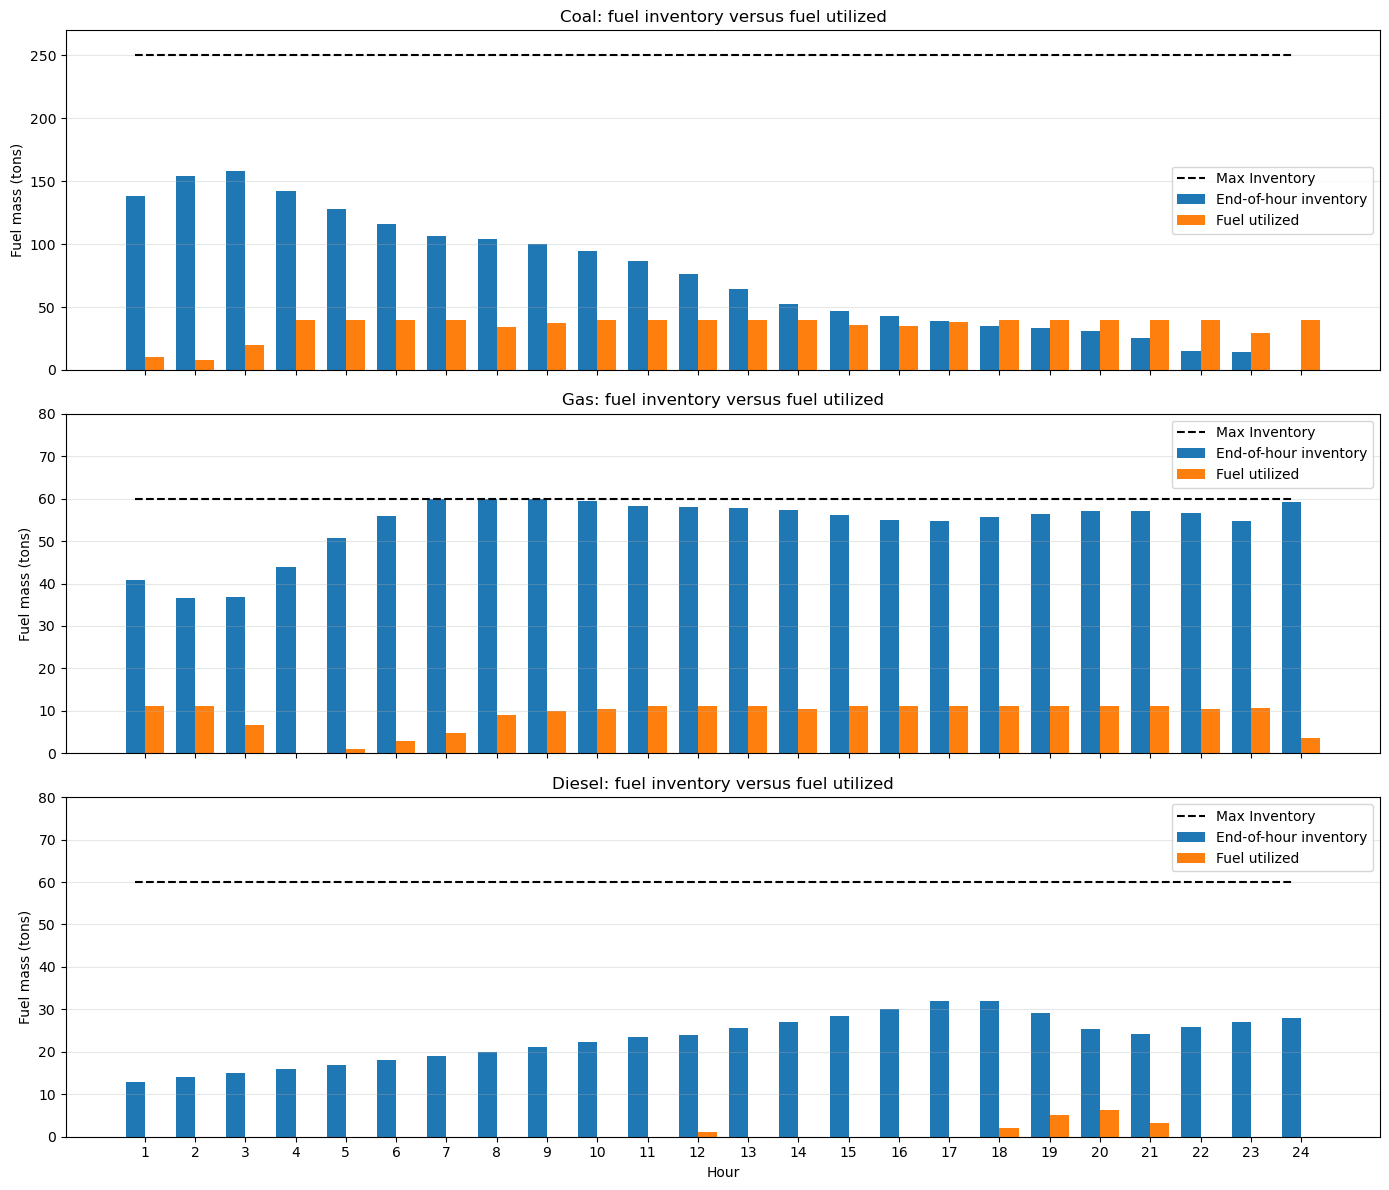

In [22]:
hours = df['Hour'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, g in zip(axes, G):
    width = 0.38

    ax.bar(hours - width/2, df[f'{g} Inventory (tons)'],
        width=width, label='End-of-hour inventory')

    ax.bar(hours + width/2, df[f'{g} Fuel Used (tons)'],
        width=width, label='Fuel utilized')

    ax.plot(hours[[0, -1]] - width/2, [Mmax[g]]*2,'k--', label='Max Inventory')
    
    ax.set_ylabel('Fuel mass (tons)')
    ax.set_ylim([0, Mmax[g]+20])
    ax.set_title(f'{g}: fuel inventory versus fuel utilized')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Hour')
axes[-1].set_xticks(hours)

plt.tight_layout()
plt.show()

## 7. Plot generator power outputs and electricity demand

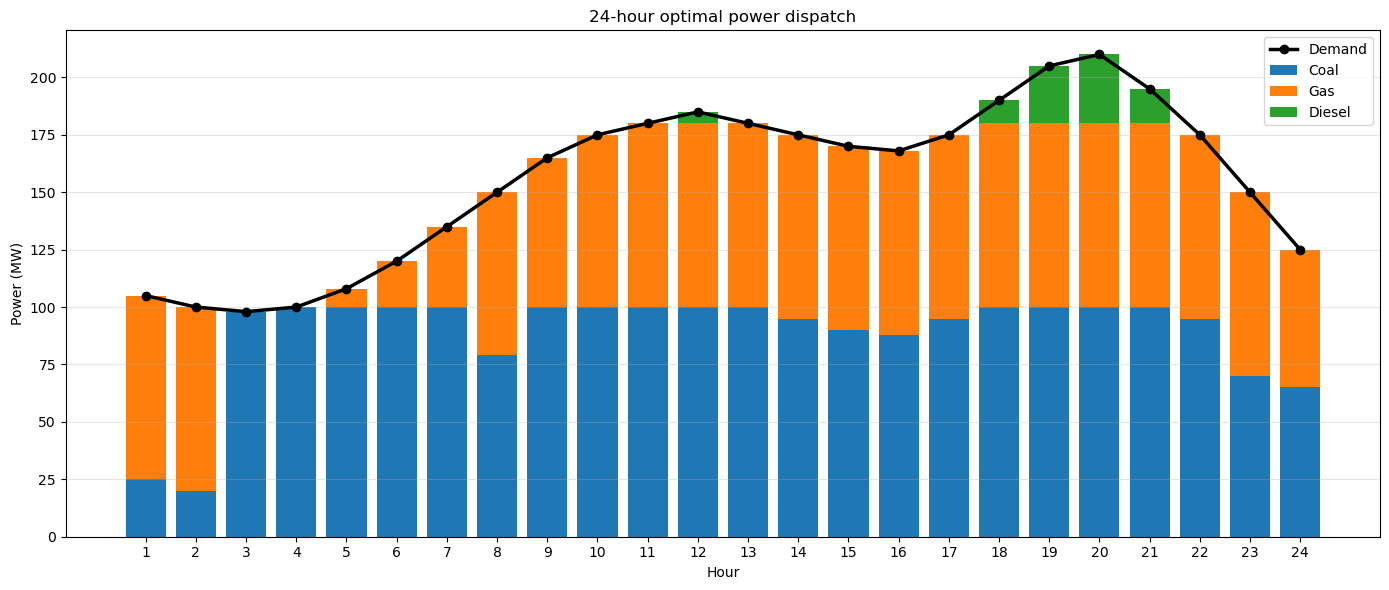

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(df))

for g in G:
    values = df[f'{g} Power (MW)'].values
    ax.bar(hours, values, bottom=bottom, label=g)
    bottom += values

ax.plot(hours, df['Demand (MW)'], marker='o',
    color='k', linewidth=2.5, label='Demand')

ax.set_xlabel('Hour')
ax.set_ylabel('Power (MW)')
ax.set_title('24-hour optimal power dispatch')
ax.set_xticks(hours)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretation

The stacked power bars should add exactly to the hourly demand line. Since coal has the lowest effective generation cost, it is generally preferred, but its use is constrained by the amount of coal physically available in inventory at each hour.

The fuel plots distinguish two quantities:

- **Fuel utilized** is the amount consumed during that particular hour.
- **Fuel inventory** is the amount remaining at the end of that hour.

Hence, a generator may have a large inventory but relatively small hourly utilization, or it may draw down its inventory during high-demand periods before later fuel deliveries replenish the stock.

If an incoming fuel delivery would cause to exceed the max inventory, the solver is forced to utilize that fuel so that the max is not exceeded.